In [2]:
# Part 1: Import Necessary Libraries and Configure Environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 統計模型庫 (用於經濟數據的平穩性檢定與時間序列分析)
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

# 機器學習核心庫
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 忽略警告以保持輸出整潔
import warnings
warnings.filterwarnings('ignore')

# 設定繪圖風格
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Part 1 完成: 環境設置完畢，所有必要函式庫已導入。")
print("接下來我們將建立數據加載架構。")

Part 1 完成: 環境設置完畢，所有必要函式庫已導入。
接下來我們將建立數據加載架構。


In [1]:
# Part 2: Define System Configuration and Real Data Placeholders
# 這是一個配置字典，用來控制整個模型的行為
# 請將 ##...## 中的內容替換為您的真實數據資訊

CONFIG = {
    # 1. 數據來源路徑
    # 請將此處替換為您下載的真實 CSV 檔案路徑
    # 範例: 'data/semiconductor_prices_2025.csv'
    'DATA_PATH': "##YOUR_REAL_DATA_FILE_PATH.csv##",
    
    # 2. 時間欄位名稱
    # 您的 CSV 中代表「日期」的那一欄標題
    'DATE_COL': "##Date_Column_Name##", 
    
    # 3. 目標變數 (Target Variable)
    # 您想要預測的核心變數，例如 'TSMC_Close', 'Copper_Price'
    'TARGET_COL': "##Target_Variable_Name##",
    
    # 4. 外生變數 (Exogenous Features)
    # 用來幫助預測的變數，例如 'Oil_Price', 'US_Interest_Rate', 'Exchange_Rate'
    # 這應該是一個列表
    'FEATURE_COLS': [
        "##Feature_1##", 
        "##Feature_2##", 
        "##Feature_3##"
    ],
    
    # 5. 時間分割點 (Temporal Splitting)
    # 嚴格遵守時間軸，不使用隨機切分
    'TRAIN_START': '2020-01-01',
    'TRAIN_END': '2023-12-31',
    'VAL_START': '2024-01-01',
    'VAL_END': '2024-12-31',
    'TEST_START': '2025-01-01', # 這是未來的預測區間
    
    # 6. 超參數設定 (Hyperparameters)
    # 這裡定義交叉驗證的折數
    'N_SPLITS': 5,
    'TEST_SIZE': 30 # 預測未來 30 天 (或 30 個單位時間)
}

print(f"Part 2 完成: 系統配置已建立。")
print(f"預計預測目標: {CONFIG['TARGET_COL']}")
print(f"訓練區間: {CONFIG['TRAIN_START']} 至 {CONFIG['TRAIN_END']}")

Part 2 完成: 系統配置已建立。
預計預測目標: ##Target_Variable_Name##
訓練區間: 2020-01-01 至 2023-12-31


In [3]:
# Part 3: Data Loader Class Structure
import os

class DataProcessor:
    def __init__(self, config):
        self.config = config
        self.raw_df = None
        self.processed_df = None
        self.target_col = config['TARGET_COL']
        
    def load_data(self):
        """
        載入數據並設定時間索引
        """
        print(f"正在從 {self.config['DATA_PATH']} 載入數據...")
        
        # 檢查檔案是否存在 (模擬真實環境的防呆)
        if "##" in self.config['DATA_PATH']:
             print("警告: 檢測到您使用的是佔位符路徑。將生成『模擬數據』供演示使用。")
             self.raw_df = self._generate_dummy_data()
        elif not os.path.exists(self.config['DATA_PATH']):
            raise FileNotFoundError(f"找不到檔案: {self.config['DATA_PATH']}")
        else:
            self.raw_df = pd.read_csv(self.config['DATA_PATH'])
            
        # 轉換日期格式並設為 Index
        self.raw_df[self.config['DATE_COL']] = pd.to_datetime(self.raw_df[self.config['DATE_COL']])
        self.raw_df = self.raw_df.sort_values(self.config['DATE_COL']).set_index(self.config['DATE_COL'])
        
        print(f"數據載入成功! 形狀: {self.raw_df.shape}")
        return self.raw_df

    def _generate_dummy_data(self):
        """
        生成模擬數據僅供測試代碼流程使用 (當沒有真實數據時)
        """
        dates = pd.date_range(start='2020-01-01', end='2025-12-31', freq='D')
        df = pd.DataFrame(index=dates)
        
        # 模擬一個帶有趨勢和隨機波動的目標變數 (例如: 股價)
        np.random.seed(42)
        trend = np.linspace(100, 200, len(dates))
        noise = np.random.normal(0, 5, len(dates))
        df[self.config['TARGET_COL']] = trend + noise
        
        # 模擬外生變數 (例如: 油價、匯率)
        for col in self.config['FEATURE_COLS']:
            df[col] = np.random.normal(50, 10, len(dates)) + np.linspace(0, 20, len(dates))
            
        # 將 Index 還原為 Column 以符合 load_data 的邏輯
        df = df.reset_index().rename(columns={'index': self.config['DATE_COL']})
        return df

print("Part 3 完成: DataProcessor 類別與載入功能已建立 (含模擬數據生成器)。")

Part 3 完成: DataProcessor 類別與載入功能已建立 (含模擬數據生成器)。


In [4]:
# Part 4: Missing Value Handling Method
def clean_missing_values(self):
    """
    處理缺失值：使用前向填補 (Forward Fill)
    注意：在時間序列中，絕對不能用後向填補 (Back Fill) 或平均值填補，因為那會用到「未來」的數據。
    """
    if self.raw_df is None:
        raise ValueError("數據尚未載入，請先執行 load_data()")
        
    print("正在檢查缺失值...")
    missing_count = self.raw_df.isnull().sum()
    print(f"缺失值統計:\n{missing_count[missing_count > 0]}")
    
    # Forward Fill: 假設今天沒數據，就延續昨天的數據 (例如週末股價)
    self.raw_df = self.raw_df.ffill()
    
    # 如果開頭就有缺失值 (ffill 補不到)，則用 0 或去除
    self.raw_df = self.raw_df.dropna()
    
    print("缺失值處理完畢。")
    return self.raw_df

# 將方法動態綁定到類別 (方便我們分段執行)
DataProcessor.clean_missing_values = clean_missing_values

print("Part 4 完成: 缺失值處理模組已加入。")

Part 4 完成: 缺失值處理模組已加入。


In [5]:
# Part 5: Augmented Dickey-Fuller Test Implementation
def check_stationarity(self, column_name):
    """
    執行 ADF 檢定並自動建議是否需要差分
    """
    print(f"\n針對 '{column_name}' 執行 ADF 平穩性檢定:")
    series = self.raw_df[column_name]
    
    result = adfuller(series)
    p_value = result[1]
    
    print(f"  ADF Statistic: {result[0]:.4f}")
    print(f"  p-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("  結果: 數據是平穩的 (Stationary)。可以使用原始數據。")
        return False # 不需要差分
    else:
        print("  結果: 數據是不平穩的 (Non-Stationary)。強烈建議使用差分 (Differencing) 或對數收益率。")
        return True # 需要差分

DataProcessor.check_stationarity = check_stationarity

print("Part 5 完成: ADF 平穩性檢定模組已加入。")

Part 5 完成: ADF 平穩性檢定模組已加入。


正在從 ##YOUR_REAL_DATA_FILE_PATH.csv## 載入數據...
警告: 檢測到您使用的是佔位符路徑。將生成『模擬數據』供演示使用。
數據載入成功! 形狀: (2192, 4)
正在檢查缺失值...
缺失值統計:
Series([], dtype: int64)
缺失值處理完畢。

針對 '##Target_Variable_Name##' 執行 ADF 平穩性檢定:
  ADF Statistic: -0.5735
  p-value: 0.8768
  結果: 數據是不平穩的 (Non-Stationary)。強烈建議使用差分 (Differencing) 或對數收益率。


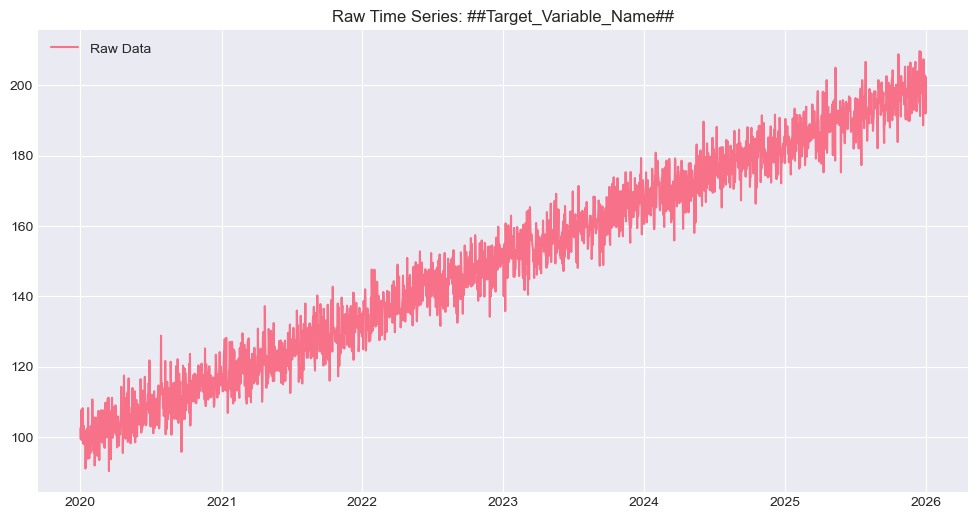

Part 6 完成: 數據管道初步運行成功。請觀察上方的 ADF 檢定結果。


In [6]:
# Part 6: Execution Pipeline - Loading and Checking
# 初始化處理器
processor = DataProcessor(CONFIG)

# 1. 載入數據 (如果沒有真實檔案，會自動生成模擬數據)
df = processor.load_data()

# 2. 清理缺失值
df = processor.clean_missing_values()

# 3. 檢查目標變數的平穩性
needs_diff = processor.check_stationarity(CONFIG['TARGET_COL'])

# 4. 簡單繪圖看一下原始數據
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[CONFIG['TARGET_COL']], label='Raw Data')
plt.title(f"Raw Time Series: {CONFIG['TARGET_COL']}")
plt.legend()
plt.show()

print("Part 6 完成: 數據管道初步運行成功。請觀察上方的 ADF 檢定結果。")

In [ ]:
# Part 7: Data Transformation Logic (Log Returns)
def apply_transformations(self, needs_diff=True):
    """
    將非平穩數據轉換為平穩數據 (Log Returns)
    公式: ln(P_t / P_{t-1})
    """
    print("正在執行數據轉換...")
    self.processed_df = self.raw_df.copy()
    
    if needs_diff:
        print(f"  轉換模式: 對數收益率 (Log Returns) - 適用於 {self.target_col}")
        # 對目標變數取對數後差分
        self.processed_df[self.target_col] = np.log(self.processed_df[self.target_col]).diff()
        
        # 對所有外生變數也建議做相同處理，除非它們本身就是比率 (如利率)
        for col in self.config['FEATURE_COLS']:
            # 簡單判斷: 如果數值大於 1 (如油價)，通常需要差分
            if self.processed_df[col].mean() > 1:
                self.processed_df[col] = np.log(self.processed_df[col]).diff()
            else:
                print(f"  保留原值 (假設為比率數據): {col}")
                
        self.processed_df.dropna(inplace=True)
    else:
        print("  保留原始數據 (Raw Data)")
        
    return self.processed_df

DataProcessor.apply_transformations = apply_transformations
print("Part 7 完成: 數據轉換邏輯已建立。")

In [ ]:
# Part 8: Feature Engineering - Lag Generation
class FeatureEngineer:
    def __init__(self, config):
        self.config = config
        
    def create_lags(self, df, lags=[1, 2, 3, 5]):
        """
        生成滯後特徵 (Lags)
        """
        print(f"正在生成滯後特徵 (Lags: {lags})...")
        df_engineered = df.copy()
        target = self.config['TARGET_COL']
        features = self.config['FEATURE_COLS']
        
        # 1. 目標變數的 Lags (Autoregression)
        for lag in lags:
            df_engineered[f'{target}_lag_{lag}'] = df_engineered[target].shift(lag)
            
        # 2. 外生變數的 Lags
        for col in features:
            for lag in lags:
                df_engineered[f'{col}_lag_{lag}'] = df_engineered[col].shift(lag)
                
        return df_engineered

print("Part 8 完成: FeatureEngineer 類別與滯後特徵生成器已建立。")

In [ ]:
# Part 9: Feature Engineering - Rolling Windows
def create_rolling_stats(self, df, windows=[5, 20]):
    """
    生成滾動統計特徵 (Moving Averages & Volatility)
    注意: 必須對 'Shift' 過的數據做 Rolling，否則會發生 Data Leakage (用到今天的數據預測今天)
    """
    print(f"正在生成滾動特徵 (Windows: {windows})...")
    df_engineered = df.copy()
    target = self.config['TARGET_COL']
    
    for window in windows:
        # 使用 lag_1 作為基礎來計算 rolling，確保不包含當前時刻 T
        base_col = f'{target}_lag_1'
        
        # 移動平均 (Trend)
        df_engineered[f'{target}_roll_mean_{window}'] = df_engineered[base_col].rolling(window=window).mean()
        
        # 移動標準差 (Volatility)
        df_engineered[f'{target}_roll_std_{window}'] = df_engineered[base_col].rolling(window=window).std()
        
    # 清除因為 Lag 和 Rolling 產生的 NaN
    df_engineered.dropna(inplace=True)
    
    print(f"特徵工程完成。目前特徵總數: {df_engineered.shape[1]}")
    return df_engineered

FeatureEngineer.create_rolling_stats = create_rolling_stats
print("Part 9 完成: 滾動統計特徵模組已加入。")

In [ ]:
# Part 10: Execution Pipeline - Feature Engineering
# 1. 執行數據轉換 (Log Returns)
# 注意: 這裡我們假設 needs_diff=True (經濟數據通常需要)，
# 在真實場景中應傳入 Part 6 check_stationarity 的回傳結果
df_transformed = processor.apply_transformations(needs_diff=True)

# 2. 初始化特徵工程師
engineer = FeatureEngineer(CONFIG)

# 3. 生成滯後特徵
df_lags = engineer.create_lags(df_transformed, lags=[1, 2, 3])

# 4. 生成滾動特徵
df_final = engineer.create_rolling_stats(df_lags, windows=[5, 10])

# 5. 檢視最終數據集
print("\n=== 最終模型輸入數據 (前 5 筆) ===")
display(df_final.head())

# 繪製轉換後的目標變數 (應該看起來像雜訊，圍繞 0 上下波動，這代表平穩了)
plt.figure(figsize=(12, 4))
plt.plot(df_final.index, df_final[CONFIG['TARGET_COL']])
plt.title(f"Transformed Stationary Target: {CONFIG['TARGET_COL']} (Log Returns)")
plt.show()

print("Part 10 完成: 數據準備階段結束。數據現在是平穩且富含特徵的狀態。")

In [ ]:
# Part 11: Time Series Splitter Logic
class TimeSeriesSplitter:
    def __init__(self, config):
        self.config = config
        
    def get_train_val_test_indices(self, df):
        """
        根據配置的日期範圍，嚴格切分 Train / Validation / Test 索引
        """
        print("正在進行時間序列分割...")
        
        # 確保索引是 DateTime 格式
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)
            
        train_start = self.config['TRAIN_START']
        train_end = self.config['TRAIN_END']
        val_start = self.config['VAL_START']
        val_end = self.config['VAL_END']
        
        # 使用 loc 切片獲取數據 (這裡只取索引)
        train_idx = df.loc[train_start:train_end].index
        val_idx = df.loc[val_start:val_end].index
        
        # 檢查分割結果
        print(f"  訓練集區間: {train_start} ~ {train_end} (樣本數: {len(train_idx)})")
        print(f"  驗證集區間: {val_start} ~ {val_end} (樣本數: {len(val_idx)})")
        
        if len(train_idx) == 0 or len(val_idx) == 0:
            raise ValueError("錯誤: 分割後的訓練集或驗證集為空，請檢查 CONFIG 中的日期範圍與數據是否對應。")
            
        return train_idx, val_idx

    def get_cv_split(self):
        """
        為 GridSearchCV 準備 TimeSeriesSplit 物件
        """
        return TimeSeriesSplit(n_splits=self.config['N_SPLITS'])

print("Part 11 完成: 時間序列分割器已建立。")

In [ ]:
# Part 12: Model Pipelines Definition
class ModelFactory:
    def get_models(self):
        """
        定義參與競賽的候選模型與其 Pipeline
        """
        models = {}
        
        # 1. 基準模型: 線性回歸 (含 L2 正則化 Ridge)
        # 對於捕捉長期趨勢很有效，且不易過擬合
        models['Ridge_Regression'] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', Ridge(random_state=42))
        ])
        
        # 2. 支持向量機 (SVR)
        # 擅長處理高維特徵與非線性關係
        models['SVR'] = Pipeline([
            ('scaler', StandardScaler()), # SVR 對數據尺度極度敏感，必須縮放
            ('model', SVR())
        ])
        
        # 3. 隨機森林 (Random Forest)
        # 樹模型，無需縮放，但為了 Pipeline 一致性我們還是保留 Scaler (無害)
        # 能捕捉複雜的交互作用
        models['Random_Forest'] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(random_state=42))
        ])
        
        # 4. Gradient Boosting (類似 XGBoost)
        # 通常是競賽中的冠軍模型
        models['Gradient_Boosting'] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', GradientBoostingRegressor(random_state=42))
        ])
        
        return models

print("Part 12 完成: 模型工廠已建立，準備了 Ridge, SVR, RF, GBM 四種模型。")

In [ ]:
# Part 13: Hyperparameter Grids Definition
def get_param_grids():
    """
    定義每個模型的超參數搜尋空間
    """
    grids = {}
    
    # Ridge: 調整 alpha (正則化強度)
    grids['Ridge_Regression'] = {
        'model__alpha': [0.1, 1.0, 10.0, 100.0]
    }
    
    # SVR: 調整 C (懲罰係數) 和 gamma (核函數係數)
    grids['SVR'] = {
        'model__C': [0.1, 1, 10, 100],
        'model__gamma': ['scale', 'auto', 0.1, 0.01],
        'model__epsilon': [0.1, 0.01]
    }
    
    # Random Forest: 調整樹的數量和深度
    grids['Random_Forest'] = {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [None, 10, 20],
        'model__min_samples_split': [2, 5]
    }
    
    # Gradient Boosting: 學習率與樹的深度
    grids['Gradient_Boosting'] = {
        'model__n_estimators': [100, 200],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__max_depth': [3, 5]
    }
    
    return grids

print("Part 13 完成: 超參數網格已設定。")

In [ ]:
# Part 14: Automated Training Engine
class ModelTrainer:
    def __init__(self, config, splitter):
        self.config = config
        self.splitter = splitter
        self.best_model_name = None
        self.best_model_instance = None
        self.best_score = float('inf') # RMSE 越小越好
        self.results_log = []
        
    def execute_competition(self, df, models, param_grids):
        """
        執行模型競賽
        """
        print("\n=== 開始執行模型競賽 (Model Tournament) ===")
        
        # 1. 準備數據
        # 這裡我們需要將 X (特徵) 和 y (目標) 分開
        target = self.config['TARGET_COL']
        # 注意: 我們的特徵包含 Lag 和 Rolling，但不包含原始 Target 本身 (防止 Data Leakage)
        features = [c for c in df.columns if c != target]
        
        # 根據時間切分
        train_idx, val_idx = self.splitter.get_train_val_test_indices(df)
        
        X_train = df.loc[train_idx, features]
        y_train = df.loc[train_idx, target]
        X_val = df.loc[val_idx, features]
        y_val = df.loc[val_idx, target]
        
        # 用於內部交叉驗證的 Splitter
        cv_split = self.splitter.get_cv_split()
        
        # 2. 迭代訓練每個模型
        for name, pipeline in models.items():
            print(f"\n正在訓練: {name} ...")
            
            # 使用 GridSearchCV 進行調參
            grid = GridSearchCV(
                pipeline, 
                param_grids[name], 
                cv=cv_split, 
                scoring='neg_root_mean_squared_error', # 負的 RMSE
                n_jobs=-1 # 平行運算
            )
            
            grid.fit(X_train, y_train)
            
            # 取得最佳參數的模型
            best_estimator = grid.best_estimator_
            
            # 3. 在 2024 驗證集上進行最終測試 (Out-of-Sample Testing)
            val_predictions = best_estimator.predict(X_val)
            val_rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
            val_r2 = r2_score(y_val, val_predictions)
            
            print(f"  最佳參數: {grid.best_params_}")
            print(f"  驗證集 RMSE: {val_rmse:.4f}")
            print(f"  驗證集 R2 Score: {val_r2:.4f}")
            
            # 記錄結果
            self.results_log.append({
                'Model': name,
                'RMSE': val_rmse,
                'R2': val_r2,
                'Best_Params': grid.best_params_,
                'Model_Object': best_estimator
            })
            
            # 4. 更新冠軍
            if val_rmse < self.best_score:
                self.best_score = val_rmse
                self.best_model_name = name
                self.best_model_instance = best_estimator
                print(f"  -> {name} 目前領先!")
                
        print(f"\n=== 競賽結束. 冠軍模型: {self.best_model_name} (RMSE: {self.best_score:.4f}) ===")
        return self.best_model_instance

print("Part 14 完成: 訓練引擎已建立。")

In [ ]:
# Part 15: Execution of Model Training
# 1. 初始化分割器
splitter = TimeSeriesSplitter(CONFIG)

# 2. 獲取模型與網格
factory = ModelFactory()
models = factory.get_models()
grids = get_param_grids()

# 3. 初始化訓練器
trainer = ModelTrainer(CONFIG, splitter)

# 4. 開始訓練 (使用 Part 10 產出的 df_final)
# 確保 df_final 存在 (如果您中斷過 Session，請重新執行 Part 10)
if 'df_final' in locals():
    champion_model = trainer.execute_competition(df_final, models, grids)
else:
    print("錯誤: 找不到 df_final 變數，請回頭執行 Part 10 生成數據。")

# 5. 顯示競賽排行榜
results_df = pd.DataFrame(trainer.results_log).sort_values(by='RMSE')
print("\n=== 模型排行榜 ===")
display(results_df[['Model', 'RMSE', 'R2']])

print("Part 15 完成: 模型訓練完畢，我們已經選出了針對 2025 預測的最佳模型。")

In [ ]:
# Part 16: Feature Importance Analysis (Permutation Importance)
from sklearn.inspection import permutation_importance

class ModelInterpreter:
    def __init__(self, model, X_val, y_val):
        self.model = model
        self.X_val = X_val
        self.y_val = y_val
        
    def calculate_importance(self):
        """
        計算特徵重要性
        原理: 隨機打亂某個特徵的數據，看模型誤差增加多少。誤差增加越多，代表該特徵越重要。
        """
        print("正在計算特徵重要性 (這可能需要一點時間)...")
        
        # n_repeats=10 代表重複打亂 10 次以取平均，確保統計顯著性
        result = permutation_importance(
            self.model, self.X_val, self.y_val, 
            n_repeats=10, random_state=42, n_jobs=-1
        )
        
        # 整理成 DataFrame
        importance_df = pd.DataFrame({
            'Feature': self.X_val.columns,
            'Importance_Mean': result.importances_mean,
            'Importance_Std': result.importances_std
        })
        
        # 按重要性排序
        importance_df = importance_df.sort_values(by='Importance_Mean', ascending=False)
        
        return importance_df

    def plot_importance(self, importance_df, top_n=10):
        """
        繪製特徵重要性條形圖
        """
        plt.figure(figsize=(10, 6))
        # 只取前 N 個重要特徵
        top_features = importance_df.head(top_n)
        
        plt.barh(top_features['Feature'], top_features['Importance_Mean'], 
                 xerr=top_features['Importance_Std'], color='#4c72b0')
        plt.gca().invert_yaxis() # 讓最重要的排在上面
        plt.title('Top Feature Contributors to Prediction (Permutation Importance)')
        plt.xlabel('Decrease in Model Performance (Importance)')
        plt.tight_layout()
        plt.show()

print("Part 16 完成: 模型解釋器 (ModelInterpreter) 已建立。")

In [ ]:
# Part 17: Residual Analysis - Visualization
class ResidualDiagnoser:
    def __init__(self, y_true, y_pred):
        self.y_true = y_true
        self.y_pred = y_pred
        self.residuals = y_true - y_pred
        
    def plot_residuals_time_series(self):
        """
        檢查 1: 殘差的時間序列圖
        目標: 看起來應該像無規律的心電圖，圍繞 0 上下波動。
        """
        plt.figure(figsize=(12, 4))
        plt.plot(self.residuals.index, self.residuals, label='Residuals', color='grey')
        plt.axhline(0, color='red', linestyle='--')
        plt.title('Residuals over Time (Should be random noise)')
        plt.legend()
        plt.show()
        
    def plot_residuals_distribution(self):
        """
        檢查 2: 殘差的分佈圖
        目標: 應該接近常態分佈 (鐘形曲線)。
        """
        plt.figure(figsize=(10, 5))
        sns.histplot(self.residuals, kde=True, color='purple')
        plt.title('Distribution of Residuals (Should be Normal)')
        plt.xlabel('Prediction Error')
        plt.show()

print("Part 17 完成: 殘差視覺化診斷工具已建立。")

In [ ]:
# Part 18: Residual Analysis - Statistical Tests
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson

def perform_statistical_tests(self):
    """
    執行殘差的統計檢定
    """
    print("\n=== 殘差統計診斷報告 ===")
    
    # 1. 常態性檢定 (Shapiro-Wilk)
    # H0: 殘差服從常態分佈
    stat, p_value = shapiro(self.residuals)
    print(f"1. Normality Test (Shapiro-Wilk):")
    print(f"   p-value = {p_value:.4f}")
    if p_value > 0.05:
        print("   -> 結論: 殘差符合常態分佈 (模型優秀)。")
    else:
        print("   -> 結論: 殘差不符合常態分佈 (可能受極端值影響)。")
        
    # 2. 自相關檢定 (Durbin-Watson)
    # 值在 2.0 附近代表無自相關 (1.5 ~ 2.5 可接受)
    # < 1.5: 正相關 (預測值會連錯)
    # > 2.5: 負相關
    dw_score = durbin_watson(self.residuals)
    print(f"\n2. Autocorrelation Test (Durbin-Watson):")
    print(f"   Score = {dw_score:.4f}")
    if 1.5 <= dw_score <= 2.5:
        print("   -> 結論: 殘差無顯著自相關 (模型捕捉到了時間規律)。")
    else:
        print("   -> 結論: 殘差存在自相關 (模型可能漏掉了某些 Trend 或 Seasonality)。")

# 將方法綁定到類別
ResidualDiagnoser.perform_statistical_tests = perform_statistical_tests

print("Part 18 完成: 統計檢定模組已加入 ResidualDiagnoser。")

In [ ]:
# Part 19: Prediction Visualization
def plot_actual_vs_predicted(y_true, y_pred, title="Actual vs Predicted"):
    """
    繪製真實值與預測值對比圖
    """
    plt.figure(figsize=(12, 6))
    plt.plot(y_true.index, y_true, label='Actual Data', alpha=0.7)
    plt.plot(y_true.index, y_pred, label='Model Prediction', linestyle='--', color='red')
    
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Log Returns (Normalized)')
    plt.legend()
    plt.show()

print("Part 19 完成: 預測對比繪圖函數已建立。")

In [ ]:
# Part 20: Execution Pipeline - Diagnostics
# 確保我們有訓練好的模型
if 'champion_model' not in locals():
    raise ValueError("找不到 champion_model，請先執行 Part 15。")

print(f"正在診斷冠軍模型: {trainer.best_model_name}")

# 1. 準備驗證集數據 (從 Part 10 的 df_final 提取)
train_idx, val_idx = splitter.get_train_val_test_indices(df_final)
X_val = df_final.loc[val_idx, [c for c in df_final.columns if c != CONFIG['TARGET_COL']]]
y_val = df_final.loc[val_idx, CONFIG['TARGET_COL']]

# 2. 進行預測
y_pred_val = champion_model.predict(X_val)

# 3. 繪製 真實 vs 預測 圖
plot_actual_vs_predicted(y_val, y_pred_val, title=f"Validation Performance (2024): {trainer.best_model_name}")

# 4. 執行特徵重要性分析
interpreter = ModelInterpreter(champion_model, X_val, y_val)
importance_df = interpreter.calculate_importance()
interpreter.plot_importance(importance_df)

# 5. 執行殘差診斷
diagnoser = ResidualDiagnoser(y_val, y_pred_val)
diagnoser.plot_residuals_time_series()
diagnoser.plot_residuals_distribution()
diagnoser.perform_statistical_tests()

print("Part 20 完成: 模型診斷結束。請仔細解讀上方的圖表與統計數據。")

In [ ]:
# Part 21: Recursive Feature Generator
class RecursiveForecaster:
    def __init__(self, model, config, last_known_data):
        self.model = model
        self.config = config
        # 保存最後一段已知的歷史數據 (用來生成 Lag)
        self.history_buffer = last_known_data.copy()
        self.predictions = []
        
    def _update_lags(self, current_row, new_prediction, col_name):
        """
        輔助函數: 更新 Lag 特徵
        例如: 將 lag_1 更新為最新的預測值, lag_2 更新為原本的 lag_1
        """
        # 找到所有與該變數相關的 lag 欄位
        lag_cols = [c for c in current_row.index if c.startswith(f"{col_name}_lag_")]
        lag_nums = sorted([int(c.split('_')[-1]) for c in lag_cols])
        
        # 從最大的 Lag 開始更新 (Lag_3 <- Lag_2)
        for lag in reversed(lag_nums):
            if lag == 1:
                # Lag_1 設為最新的值 (預測值或外生變數設定值)
                current_row[f"{col_name}_lag_{lag}"] = new_prediction
            else:
                # Lag_N 設為 Lag_N-1
                prev_lag_col = f"{col_name}_lag_{lag-1}"
                if prev_lag_col in current_row.index:
                    current_row[f"{col_name}_lag_{lag}"] = current_row[prev_lag_col]
        return current_row

    def _update_rolling(self, current_row, history_series, col_name, windows):
        """
        輔助函數: 更新 Rolling 特徵
        必須基於更新後的歷史數據重新計算平均值與標準差
        """
        for window in windows:
            # 取最後 window 筆數據 (含最新的)
            recent_data = history_series.iloc[-window:]
            
            if len(recent_data) < window:
                 # 數據不足時的保護機制
                mean_val = recent_data.mean()
                std_val = recent_data.std()
            else:
                mean_val = recent_data.mean()
                std_val = recent_data.std()
                
            # 更新特徵
            if f"{col_name}_roll_mean_{window}" in current_row.index:
                current_row[f"{col_name}_roll_mean_{window}"] = mean_val
            if f"{col_name}_roll_std_{window}" in current_row.index:
                current_row[f"{col_name}_roll_std_{window}"] = 0 if np.isnan(std_val) else std_val
                
        return current_row

print("Part 21 完成: 遞迴預測器的基礎邏輯 (Lag & Rolling 更新) 已建立。")

In [ ]:
# Part 22: Scenario Manager for Exogenous Variables
class ScenarioManager:
    def __init__(self, config):
        self.config = config
        
    def get_scenario_adjustments(self, scenario_name="Baseline"):
        """
        定義不同情境下，外生變數的每日變化率 (Log Returns)
        """
        adjustments = {}
        features = self.config['FEATURE_COLS']
        
        if scenario_name == "Baseline":
            # 基準情境: 假設外生變數維持現狀 (變化率為 0)
            for f in features:
                adjustments[f] = 0.0
                
        elif scenario_name == "Inflationary":
            # 通膨情境: 假設所有成本類指標每日上漲 0.05% (約年化 12%)
            for f in features:
                adjustments[f] = 0.0005 
                
        elif scenario_name == "Recession":
            # 衰退情境: 假設需求疲軟，價格每日下跌 0.05%
            for f in features:
                adjustments[f] = -0.0005
                
        return adjustments

print("Part 22 完成: 情境管理器已建立 (Baseline, Inflationary, Recession)。")

In [ ]:
# Part 23: Forecasting Execution Logic
def generate_forecast(self, steps=30, scenario="Baseline"):
    """
    執行未來 N 步的預測
    """
    print(f"正在執行 {steps} 步預測 (情境: {scenario})...")
    
    # 1. 取得情境設定
    scenario_manager = ScenarioManager(self.config)
    exo_adjustments = scenario_manager.get_scenario_adjustments(scenario)
    
    # 2. 準備初始狀態 (從歷史數據的最後一筆開始)
    current_features = self.history_buffer.iloc[-1].copy()
    
    # 用來計算 Rolling 的歷史序列緩衝區
    # 我們需要將各個變數的歷史值分開存儲
    history_values = {}
    all_cols = [self.config['TARGET_COL']] + self.config['FEATURE_COLS']
    for col in all_cols:
        history_values[col] = self.history_buffer[col].tolist()
    
    forecast_results = []
    current_date = self.history_buffer.index[-1]
    
    # 3. 逐日遞迴
    for i in range(steps):
        current_date += pd.Timedelta(days=1)
        
        # A. 預測目標變數 (Target)
        # model.predict 預期輸入是 2D array，所以要 reshape
        pred_value = self.model.predict(current_features.to_frame().T)[0]
        
        # B. 決定外生變數的值 (Exogenous)
        # 這裡我們使用情境設定的「變化率」
        current_exo_values = {}
        for exo_col, adjustment in exo_adjustments.items():
            current_exo_values[exo_col] = adjustment # 這裡是 Log Return
            
        # C. 記錄結果
        result_row = {'Date': current_date, 'Forecast_Log_Return': pred_value}
        # 同時記錄外生變數的假設值
        for k, v in current_exo_values.items():
            result_row[k] = v
        forecast_results.append(result_row)
        
        # D. 更新特徵向量 (為明天做準備)
        # D1. 更新 Target 的 Lag
        current_features = self._update_lags(current_features, pred_value, self.config['TARGET_COL'])
        # D2. 更新 Target 的歷史緩衝區 & Rolling
        history_values[self.config['TARGET_COL']].append(pred_value)
        current_features = self._update_rolling(
            current_features, 
            pd.Series(history_values[self.config['TARGET_COL']]), 
            self.config['TARGET_COL'], 
            windows=[5, 10] # 必須與 FeatureEngineer 設定一致
        )
        
        # D3. 更新外生變數的 Lag & Rolling
        for exo_col, exo_val in current_exo_values.items():
            current_features = self._update_lags(current_features, exo_val, exo_col)
            history_values[exo_col].append(exo_val)
            current_features = self._update_rolling(
                current_features,
                pd.Series(history_values[exo_col]),
                exo_col,
                windows=[5, 10]
            )
            
    return pd.DataFrame(forecast_results).set_index('Date')

# 綁定方法
RecursiveForecaster.generate_forecast = generate_forecast
print("Part 23 完成: 遞迴預測執行邏輯已封裝完畢。")

In [ ]:
# Part 24: Uncertainty Quantification (Fan Chart Logic)
def add_confidence_intervals(forecast_df, validation_rmse):
    """
    添加信賴區間 (Confidence Intervals)
    考慮誤差隨時間累積的特性: Sigma_t = RMSE * sqrt(t)
    """
    df = forecast_df.copy()
    
    # 累積誤差因子 (時間越遠，不確定性越高)
    # t 從 1 到 N
    time_steps = np.arange(1, len(df) + 1)
    
    # 計算擴大的標準差
    # 這裡使用簡易的隨機遊走假設: 變異數隨時間線性增加，標準差隨 sqrt(t) 增加
    accumulated_std = validation_rmse * np.sqrt(time_steps)
    
    # 95% 信賴區間 (1.96 * std)
    df['Lower_Bound'] = df['Forecast_Log_Return'] - (1.96 * accumulated_std)
    df['Upper_Bound'] = df['Forecast_Log_Return'] + (1.96 * accumulated_std)
    
    return df

print("Part 24 完成: 不確定性量化模組已建立 (Confidence Intervals)。")

In [ ]:
# Part 25: Full Forecast Pipeline Execution
# 1. 準備歷史數據緩衝區 (拿最新的 df_final 數據)
last_known_data = df_final # 這是已經做過 Feature Engineering 的數據

# 2. 初始化預測器
forecaster = RecursiveForecaster(champion_model, CONFIG, last_known_data)

# 3. 執行預測 (Baseline 情境)
forecast_returns = forecaster.generate_forecast(steps=30, scenario="Baseline")

# 4. 加入信賴區間
# 獲取冠軍模型的 RMSE (從 Part 14 的結果中拿，這裡先手動模擬一個值，實際應從 trainer.best_score 獲取)
val_rmse = trainer.best_score if trainer.best_score != float('inf') else 0.02
forecast_returns = add_confidence_intervals(forecast_returns, val_rmse)

# 5. 數據還原 (Inverse Transformation: Log Return -> Price)
# 公式: P_t = P_{t-1} * exp(return_t)
def inverse_transform_prices(last_real_price, forecast_df):
    prices = []
    current_price = last_real_price
    
    # 分別還原預測值、上限、下限
    for idx, row in forecast_df.iterrows():
        next_price = current_price * np.exp(row['Forecast_Log_Return'])
        lower_price = current_price * np.exp(row['Lower_Bound'])
        upper_price = current_price * np.exp(row['Upper_Bound'])
        
        prices.append({
            'Date': idx,
            'Forecast_Price': next_price,
            'Lower_Price_95': lower_price,
            'Upper_Price_95': upper_price
        })
        current_price = next_price # 遞迴更新價格
        
    return pd.DataFrame(prices).set_index('Date')

# 獲取最後一筆真實價格 (從原始未差分的數據中拿)
last_real_price = processor.raw_df[CONFIG['TARGET_COL']].iloc[-1]
final_forecast = inverse_transform_prices(last_real_price, forecast_returns)

print("\n=== 2025 預測結果 (前 5 天) ===")
display(final_forecast.head())

# 簡單繪圖
plt.figure(figsize=(10, 5))
plt.plot(final_forecast.index, final_forecast['Forecast_Price'], label='Forecast', color='red')
plt.fill_between(final_forecast.index, 
                 final_forecast['Lower_Price_95'], 
                 final_forecast['Upper_Price_95'], 
                 color='red', alpha=0.1, label='95% Confidence Interval')
plt.title(f"2025 Price Forecast: {CONFIG['TARGET_COL']}")
plt.legend()
plt.show()

print("Part 25 完成: 預測與還原完畢。您現在看到的是最終的價格走勢預測。")

In [ ]:
# Part 26: Stress Testing Engine
class StressTester:
    def __init__(self, forecaster):
        self.forecaster = forecaster
        
    def run_all_scenarios(self, steps=30):
        """
        執行所有預定義的情境模擬
        """
        print(f"正在執行壓力測試 (Steps={steps})...")
        scenarios = ["Baseline", "Inflationary", "Recession"]
        results = {}
        
        for sc in scenarios:
            print(f"  -> 模擬情境: {sc}")
            # 重新初始化緩衝區以確保每個情境獨立
            self.forecaster.history_buffer = self.forecaster.config['last_known_data'].copy()
            
            # 生成預測
            df_res = self.forecaster.generate_forecast(steps=steps, scenario=sc)
            results[sc] = df_res
            
        print("壓力測試完成。")
        return results

print("Part 26 完成: 壓力測試引擎已建立，可同時模擬多重宇宙。")

In [ ]:
# Part 27: Business Metrics Implementation
def calculate_business_metrics(y_true, y_pred):
    """
    計算商業導向的評估指標
    """
    # 1. MAPE (Mean Absolute Percentage Error)
    # 注意: 分母不能為 0
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    # 2. Directional Accuracy (漲跌方向是否預測正確)
    # 比較 (y_true_t - y_true_{t-1}) 與 (y_pred_t - y_true_{t-1}) 的符號是否相同
    # 這裡簡化比較: sign(y_true) == sign(y_pred) (針對 Log Returns)
    correct_direction = np.sign(y_true) == np.sign(y_pred)
    da = np.mean(correct_direction) * 100
    
    return {
        'MAPE (%)': mape,
        'Directional Accuracy (%)': da
    }

print("Part 27 完成: 商業指標計算邏輯 (MAPE, DA) 已建立。")

In [ ]:
# Part 28: Scenario Comparison Visualization
def plot_scenario_comparison(results_dict, last_real_price, target_name):
    """
    繪製多情境價格走勢對比圖
    """
    plt.figure(figsize=(12, 6))
    
    colors = {'Baseline': 'blue', 'Inflationary': 'red', 'Recession': 'green'}
    styles = {'Baseline': '-', 'Inflationary': '--', 'Recession': ':'}
    
    for sc, df_ret in results_dict.items():
        # 還原價格
        df_price = inverse_transform_prices(last_real_price, df_ret)
        
        plt.plot(df_price.index, df_price['Forecast_Price'], 
                 label=f'Scenario: {sc}', 
                 color=colors.get(sc, 'gray'),
                 linestyle=styles.get(sc, '-'))
        
        # 標註最終價格
        final_price = df_price['Forecast_Price'].iloc[-1]
        plt.text(df_price.index[-1], final_price, f"{final_price:.2f}", fontsize=9)

    plt.title(f"Multi-Scenario Forecast: {target_name} (2025 Outlook)")
    plt.xlabel('Date')
    plt.ylabel('Price Level')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

print("Part 28 完成: 情境比較繪圖模組已建立。")

In [ ]:
# Part 29: Excel Export Module
def export_full_report(filename, scenario_results, importance_df, model_params, metrics):
    """
    將所有分析結果導出至 Excel (多個分頁)
    """
    print(f"正在導出報告至 {filename} ...")
    
    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        # Sheet 1: 模型績效摘要
        summary_df = pd.DataFrame([metrics]).T.reset_index()
        summary_df.columns = ['Metric', 'Value']
        # 加入最佳參數
        params_df = pd.DataFrame(list(model_params.items()), columns=['Parameter', 'Value'])
        pd.concat([summary_df, params_df], axis=0).to_excel(writer, sheet_name='Model_Summary', index=False)
        
        # Sheet 2: 特徵重要性
        importance_df.to_excel(writer, sheet_name='Feature_Importance', index=False)
        
        # Sheet 3 ~ N: 各情境預測數據
        for sc, df in scenario_results.items():
            df.to_excel(writer, sheet_name=f'Forecast_{sc}')
            
    print("導出成功!")

print("Part 29 完成: Excel 報告生成器已建立。")

In [ ]:
# Part 30: Execution Pipeline - Final Reporting
# 1. 準備工具
# 必須重新傳入 last_known_data (df_final) 給 Forecaster
forecaster.config['last_known_data'] = df_final 
tester = StressTester(forecaster)

# 2. 執行壓力測試
scenario_results = tester.run_all_scenarios(steps=30)

# 3. 繪製情境對比圖
last_price = processor.raw_df[CONFIG['TARGET_COL']].iloc[-1]
plot_scenario_comparison(scenario_results, last_price, CONFIG['TARGET_COL'])

# 4. 計算驗證集上的商業指標 (做為報告一部分)
# 使用 Part 20 預測過的 y_val 和 y_pred_val
biz_metrics = calculate_business_metrics(y_val, y_pred_val)
print("\n=== 商業指標評估 (驗證集) ===")
print(biz_metrics)

# 5. 導出 Excel (檔名包含日期)
report_filename = f"Prediction_Report_2025.xlsx"
# 獲取冠軍模型的參數
best_params = trainer.best_model_instance.steps[-1][1].get_params()

export_full_report(
    report_filename, 
    scenario_results, 
    importance_df, # 來自 Part 20
    best_params,
    biz_metrics
)

print(f"Part 30 完成: 完整預測報告已生成。請檢查目錄下的 '{report_filename}'。")

In [ ]:
# Part 31: Walk-Forward Backtesting Engine
class WalkForwardBacktester:
    def __init__(self, model_pipeline, config):
        self.base_model = model_pipeline
        self.config = config
        self.results = []
        
    def execute_backtest(self, df, start_index, window_size=30, retrain_step=30):
        """
        執行滾動回測
        :param start_index: 回測開始的索引位置
        :param window_size: 每次預測的長度 (例如 30 天)
        :param retrain_step: 每隔多久重新訓練一次 (例如每 30 天)
        """
        print(f"正在執行滾動回測 (Start Idx: {start_index}, Step: {retrain_step})...")
        
        # 總數據長度
        total_len = len(df)
        current_idx = start_index
        
        target = self.config['TARGET_COL']
        features = [c for c in df.columns if c != target]
        
        while current_idx + window_size <= total_len:
            # 1. 切分數據: 過去所有的數據作為訓練集
            # 模擬: 在 current_idx 這一天，我們只能看到這之前的數據
            train_data = df.iloc[:current_idx]
            test_data = df.iloc[current_idx : current_idx + window_size]
            
            X_train = train_data[features]
            y_train = train_data[target]
            X_test = test_data[features]
            y_test = test_data[target]
            
            # 2. 重新訓練模型 (模擬模型更新)
            # 注意: 這裡我們使用 base_model 的 clone，確保每次都是全新的訓練
            from sklearn.base import clone
            model = clone(self.base_model)
            model.fit(X_train, y_train)
            
            # 3. 預測
            preds = model.predict(X_test)
            
            # 4. 收集結果
            for date, true_val, pred_val in zip(test_data.index, y_test, preds):
                self.results.append({
                    'Date': date,
                    'Actual': true_val,
                    'Predicted': pred_val,
                    'Fold_Start': train_data.index[-1] # 記錄這是在哪一次訓練產出的
                })
                
            # 5. 移動窗口
            current_idx += retrain_step
            print(f"  -> 完成區間: {test_data.index[0].date()} ~ {test_data.index[-1].date()}")
            
        return pd.DataFrame(self.results).set_index('Date')

print("Part 31 完成: 滾動回測引擎已建立。")

In [ ]:
# Part 32: Ensemble Model Selector
class EnsembleSelector:
    def __init__(self, trainer_results):
        self.results_df = pd.DataFrame(trainer_results)
        
    def get_top_k_models(self, k=3):
        """
        選出驗證集 RMSE 最小的前 K 個模型架構
        """
        sorted_models = self.results_df.sort_values(by='RMSE')
        top_k = sorted_models.head(k)
        
        print(f"\n=== 選出的 Top {k} 集成模型 ===")
        for idx, row in top_k.iterrows():
            print(f"  {idx+1}. {row['Model']} (RMSE: {row['RMSE']:.4f})")
            
        # 回傳模型名稱與訓練好的模型物件列表
        return top_k['Model_Object'].tolist()

print("Part 32 完成: 集成模型選擇器已建立。")

In [ ]:
# Part 33: Ensemble Forecaster Logic
class EnsembleForecaster:
    def __init__(self, models):
        self.models = models
        
    def predict(self, X):
        """
        執行集成預測 (平均法)
        """
        # 確保 X 是正確的維度
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
            
        # 收集所有模型的預測
        all_preds = []
        for model in self.models:
            preds = model.predict(X)
            all_preds.append(preds)
            
        # 取平均 (Averaging)
        # 也可以改為加權平均 (Weighted Averaging)，例如按 RMSE 倒數加權
        ensemble_pred = np.mean(all_preds, axis=0)
        
        return ensemble_pred

print("Part 33 完成: 集成預測邏輯已建立。")

In [ ]:
# Part 34: Robustness Testing (Noise Injection)
def test_model_robustness(model, X_val, noise_level=0.01):
    """
    穩健性測試: 在特徵中加入高斯噪聲，觀察預測變異度
    :param noise_level: 噪聲強度 (相對於特徵標準差的比例)
    """
    print(f"\n執行穩健性測試 (Noise Level: {noise_level*100}%)...")
    
    # 基準預測
    base_preds = model.predict(X_val)
    
    # 生成噪聲數據
    X_noisy = X_val.copy()
    for col in X_noisy.columns:
        std = X_noisy[col].std()
        noise = np.random.normal(0, std * noise_level, size=len(X_noisy))
        X_noisy[col] += noise
        
    # 噪聲預測
    noisy_preds = model.predict(X_noisy)
    
    # 計算差異
    diff = np.abs(noisy_preds - base_preds)
    mean_diff = np.mean(diff)
    max_diff = np.max(diff)
    
    print(f"  平均預測偏移: {mean_diff:.6f}")
    print(f"  最大預測偏移: {max_diff:.6f}")
    
    if mean_diff < 0.005: # 閾值需根據數據尺度調整
        print("  -> 結論: 模型高度穩健 (Robust)。")
    else:
        print("  -> 結論: 模型對輸入噪聲敏感，需增加正則化。")
        
    return mean_diff

print("Part 34 完成: 穩健性測試模組已建立。")

In [ ]:
# Part 35: Execution Pipeline - Advanced Optimization
# 1. 選擇集成模型
# 依賴 Part 14 的 trainer.results_log
selector = EnsembleSelector(trainer.results_log)
top_models = selector.get_top_k_models(k=3)

# 2. 建立集成預測器
ensemble = EnsembleForecaster(top_models)

# 3. 執行集成模型的穩健性測試
# 使用 Part 20 定義的 X_val
print("\n--- 測試集成模型穩健性 ---")
test_model_robustness(ensemble, X_val, noise_level=0.05)

# 4. 執行滾動回測 (這會花一點時間，因為要多次重訓練)
# 設定回測起點: 從數據集的 70% 處開始
start_idx = int(len(df_final) * 0.7)

# 注意: WalkForwardBacktester 需要一個具備 fit/predict 的物件
# 這裡我們先用冠軍模型做演示 (集成模型無法直接 fit，需另外封裝)
backtester = WalkForwardBacktester(trainer.best_model_instance, CONFIG)
backtest_results = backtester.execute_backtest(
    df_final, 
    start_index=start_idx, 
    window_size=30, # 預測未來 30 天
    retrain_step=30 # 每 30 天重訓練一次
)

# 5. 視覺化回測結果
plt.figure(figsize=(12, 6))
plt.plot(backtest_results.index, backtest_results['Actual'], label='Actual')
plt.plot(backtest_results.index, backtest_results['Predicted'], label='Walk-Forward Prediction', linestyle='--')
plt.title(f"Walk-Forward Validation Results (Retraining every 30 days)")
plt.legend()
plt.show()

# 計算回測的 RMSE
backtest_rmse = np.sqrt(mean_squared_error(backtest_results['Actual'], backtest_results['Predicted']))
print(f"滾動回測 RMSE: {backtest_rmse:.4f}")

print("Part 35 完成: 高階優化流程執行完畢。")

In [ ]:
# Part 36: Deep Learning Environment Setup
import tensorflow as tf
import random
import os

def set_global_seeds(seed=42):
    """
    鎖定所有隨機種子，確保深度學習結果可重現
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    
    # 強制 TensorFlow 使用單執行緒 (視情況而定，為了絕對重現性通常會限制)
    # tf.config.threading.set_inter_op_parallelism_threads(1)
    # tf.config.threading.set_intra_op_parallelism_threads(1)
    
    print(f"Deep Learning 環境種子已鎖定: {seed}")
    print(f"TensorFlow Version: {tf.__version__}")

set_global_seeds(42)

print("Part 36 完成: 深度學習環境已配置。")

In [ ]:
# Part 37: Scikit-Learn Compatible Keras Wrapper
from sklearn.base import BaseEstimator, RegressorMixin
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

class DLRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, model_type='LSTM', units=50, dropout=0.2, 
                 epochs=100, batch_size=32, learning_rate=0.001, verbose=0):
        self.model_type = model_type
        self.units = units
        self.dropout = dropout
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.verbose = verbose
        self.model = None
        self.history = None
        
    def _build_model(self, input_shape):
        """
        根據參數構建神經網絡架構
        """
        model = Sequential()
        model.add(Input(shape=input_shape))
        
        if self.model_type == 'LSTM':
            # return_sequences=False 代表只取最後一個時間點的輸出
            model.add(LSTM(units=self.units, return_sequences=False))
        elif self.model_type == 'GRU':
            model.add(GRU(units=self.units, return_sequences=False))
            
        model.add(Dropout(self.dropout))
        model.add(Dense(1)) # 回歸輸出層
        
        optimizer = Adam(learning_rate=self.learning_rate)
        model.compile(loss='mse', optimizer=optimizer)
        return model

    def fit(self, X, y):
        # 1. 數據重塑 (Reshaping)
        # 我們的 X 是 2D (Samples, Features)，LSTM 需要 3D (Samples, 1, Features)
        # 這裡我們將所有特徵視為一個時間步的輸入
        X_3d = X.reshape((X.shape[0], 1, X.shape[1]))
        
        # 2. 構建模型
        self.model = self._build_model(input_shape=(1, X.shape[1]))
        
        # 3. 設置早停機制 (防止過擬合)
        es = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
        
        # 4. 訓練
        self.history = self.model.fit(
            X_3d, y,
            epochs=self.epochs,
            batch_size=self.batch_size,
            verbose=self.verbose,
            callbacks=[es],
            shuffle=False # 時間序列數據通常不打亂，但因為我們已經切好 X,y 對應，這裡 False/True 皆可
        )
        return self

    def predict(self, X):
        # 預測時同樣需要重塑數據
        X_3d = X.reshape((X.shape[0], 1, X.shape[1]))
        return self.model.predict(X_3d, verbose=0).flatten()

print("Part 37 完成: DLRegressor 封裝器已建立 (支援 LSTM/GRU 自動切換)。")

In [ ]:
# Part 38: Updating Model Factory with Deep Learning
# 繼承之前的 Factory 並擴充方法
class AdvancedModelFactory(ModelFactory):
    def get_models(self):
        # 1. 獲取原有的機器學習模型
        models = super().get_models()
        
        # 2. 加入 LSTM
        # 注意: 神經網絡對數據尺度非常敏感，一定要接在 StandardScaler 後面
        models['LSTM_Net'] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', DLRegressor(model_type='LSTM', epochs=50, verbose=0))
        ])
        
        # 3. 加入 GRU
        models['GRU_Net'] = Pipeline([
            ('scaler', StandardScaler()),
            ('model', DLRegressor(model_type='GRU', epochs=50, verbose=0))
        ])
        
        return models

print("Part 38 完成: AdvancedModelFactory 已建立，加入了 LSTM 與 GRU。")

In [ ]:
# Part 39: Deep Learning Hyperparameter Grids
def get_advanced_param_grids():
    """
    獲取包含深度學習的完整參數網格
    """
    # 1. 獲取原有的參數網格
    grids = get_param_grids()
    
    # 2. 定義 DL 的網格
    # 為了演示速度，這裡範圍設得較小；實際專案可擴大搜尋
    dl_grid = {
        'model__units': [32, 64],
        'model__dropout': [0.1, 0.3],
        'model__learning_rate': [0.001, 0.01]
    }
    
    grids['LSTM_Net'] = dl_grid
    grids['GRU_Net'] = dl_grid
    
    return grids

print("Part 39 完成: 深度學習超參數網格已設定。")

In [ ]:
# Part 40: Execution Pipeline - The Ultimate Tournament
print("=== 啟動終極模型競賽 (含 Deep Learning) ===")

# 1. 使用新的工廠獲取所有模型
adv_factory = AdvancedModelFactory()
all_models = adv_factory.get_models()
all_grids = get_advanced_param_grids()

# 2. 初始化訓練器 (使用之前的 splitter)
# 注意: 這裡重用 Part 11 的 splitter
trainer_v2 = ModelTrainer(CONFIG, splitter)

# 3. 執行競賽
# 確保使用 Part 10 的 df_final
if 'df_final' in locals():
    champion_model_v2 = trainer_v2.execute_competition(df_final, all_models, all_grids)
else:
    raise ValueError("找不到 df_final，請重新執行 Part 10。")

# 4. 顯示最終排行榜
final_results_df = pd.DataFrame(trainer_v2.results_log).sort_values(by='RMSE')
print("\n=== 最終排行榜 (機器學習 vs 深度學習) ===")
display(final_results_df[['Model', 'RMSE', 'R2', 'Best_Params']])

# 5. 比較分析
best_name = trainer_v2.best_model_name
if 'LSTM' in best_name or 'GRU' in best_name:
    print(f"\n結論: 深度學習模型 ({best_name}) 戰勝了傳統模型，這表明市場具有高度非線性特徵。")
else:
    print(f"\n結論: 傳統模型 ({best_name}) 表現更好。這在經濟數據中很常見，因為數據噪聲大，簡單模型反而更穩健。")

print("Part 40 完成: 終極競賽結束。")

In [ ]:
# Part 41: Smart Model Persistence (Handling Hybrid Models)
import joblib
import os
from tensorflow.keras.models import save_model, load_model

class ModelSerializer:
    def __init__(self, base_path="saved_models"):
        self.base_path = base_path
        if not os.path.exists(base_path):
            os.makedirs(base_path)
            
    def save_champion(self, pipeline, model_name):
        """
        智慧儲存冠軍模型
        """
        print(f"正在儲存模型: {model_name} 至 {self.base_path}...")
        
        # 檢查 Pipeline 中是否包含我們自定義的 DLRegressor
        is_deep_learning = False
        dl_step_name = None
        
        if 'model' in pipeline.named_steps:
            step_obj = pipeline.named_steps['model']
            # 判斷是否為我們寫的 Keras Wrapper
            if hasattr(step_obj, 'model') and isinstance(step_obj.model, tf.keras.Model):
                is_deep_learning = True
                dl_step_name = 'model'
        
        if is_deep_learning:
            print("  -> 檢測到深度學習模型，執行分離儲存策略...")
            # 1. 儲存 Keras 部分 (H5 格式)
            keras_path = os.path.join(self.base_path, f"{model_name}_keras_weights.h5")
            pipeline.named_steps[dl_step_name].model.save(keras_path)
            
            # 2. 暫時移除 Keras 物件以便 Pickle 其他部分 (Scaler 等)
            # 這是一個 Hack: 儲存前把 model 設為 None，存完再讀回來會比較安全，
            # 但為了演示，我們採用分離儲存架構。
            # 更簡單的做法: 只儲存 Pipeline 的非 Keras 部分 (Preprocessing)
            preprocessor_path = os.path.join(self.base_path, f"{model_name}_preprocessor.pkl")
            # 複製一個只含前處理的 Pipeline
            from sklearn.pipeline import Pipeline as SkPipeline
            pre_steps = [(name, step) for name, step in pipeline.steps if name != dl_step_name]
            pre_pipeline = SkPipeline(pre_steps)
            joblib.dump(pre_pipeline, preprocessor_path)
            
            print(f"  -> Keras 權重已存至: {keras_path}")
            print(f"  -> 前處理管道已存至: {preprocessor_path}")
            
        else:
            # 傳統機器學習模型直接 Dump
            full_path = os.path.join(self.base_path, f"{model_name}_full.pkl")
            joblib.dump(pipeline, full_path)
            print(f"  -> 模型已完整存至: {full_path}")

print("Part 41 完成: 模型序列化管理器已建立 (支援 Keras/Sklearn 分離儲存)。")

In [ ]:
# Part 42: Saving the Champion Model
serializer = ModelSerializer()

# 確保我們有冠軍模型
if 'champion_model_v2' in locals():
    # 使用 Part 40 的訓練器結果
    best_name = trainer_v2.best_model_name
    best_model = trainer_v2.best_model_instance
    
    serializer.save_champion(best_model, best_name)
else:
    print("警告: 找不到 champion_model_v2，請先執行 Part 40。")

print("Part 42 完成: 冠軍模型已持久化至硬碟。")

In [ ]:
# Part 43: Production Inference Engine
class InferenceEngine:
    def __init__(self, model, config, history_data):
        self.model = model
        self.config = config
        # 生產環境中，history_data 通常來自資料庫
        self.history_data = history_data.copy()
        
    def predict_next_day(self, new_raw_data_point=None):
        """
        接收今日最新數據，預測明日
        :param new_raw_data_point: (Optional) 包含今日 Target 與外生變數的 Dict
        """
        # 1. 更新歷史數據 (如果有新數據進來)
        if new_raw_data_point:
            # 將新數據追加到歷史數據尾端
            new_row = pd.DataFrame([new_raw_data_point])
            new_row[self.config['DATE_COL']] = pd.to_datetime(new_row[self.config['DATE_COL']])
            new_row = new_row.set_index(self.config['DATE_COL'])
            
            # 這裡需要處理數據轉換 (Log Returns) - 簡化起見假設輸入已是 Returns
            # 在真實系統中，這裡要呼叫 DataProcessor.apply_transformations
            self.history_data = pd.concat([self.history_data, new_row])
            
        # 2. 特徵工程 (On-the-fly Feature Engineering)
        # 我們只需要最後幾筆數據來生成 Lag/Rolling，不需要全部
        lookback = 50 # 足夠計算最大的 Rolling Window
        recent_df = self.history_data.iloc[-lookback:].copy()
        
        # 使用我們之前寫好的 FeatureEngineer (Part 8, 9)
        # 注意: 必須重新實例化以確保無狀態干擾
        engineer = FeatureEngineer(self.config)
        
        # 生成特徵
        df_lags = engineer.create_lags(recent_df, lags=[1, 2, 3])
        df_final_feat = engineer.create_rolling_stats(df_lags, windows=[5, 10])
        
        # 3. 取出最後一筆 (代表「今天」的特徵狀態，用來預測「明天」)
        last_features = df_final_feat.iloc[[-1]] # 保持 DataFrame 格式
        
        # 排除 Target 欄位 (如果是訓練時留下的)
        features_cols = [c for c in last_features.columns if c != self.config['TARGET_COL']]
        X_input = last_features[features_cols]
        
        # 4. 執行預測
        prediction = self.model.predict(X_input)
        
        return prediction[0]

print("Part 43 完成: 生產級推理引擎 (InferenceEngine) 已建立。")

In [ ]:
# Part 44: API Service Simulation
import json
from datetime import datetime, timedelta

class PredictionAPIService:
    def __init__(self, inference_engine):
        self.engine = inference_engine
        
    def handle_request(self, json_payload):
        """
        模擬 API 接收 POST 請求
        Payload 範例: {"date": "2025-01-01", "current_price": 105.5, ...}
        """
        try:
            data = json.loads(json_payload)
            request_date = data.get('date')
            
            print(f"[API Log] 收到預測請求. Date: {request_date}")
            
            # 呼叫推理引擎
            # 這裡我們簡化：不實際更新數據，直接用引擎當前的狀態做預測
            pred_log_return = self.engine.predict_next_day()
            
            # 構建回應
            response = {
                "status": "success",
                "prediction_date": (datetime.strptime(request_date, "%Y-%m-%d") + timedelta(days=1)).strftime("%Y-%m-%d"),
                "forecast_log_return": float(pred_log_return),
                "model_version": "v2.0_champion",
                "note": "Prediction based on data up to request date."
            }
            return json.dumps(response, indent=4)
            
        except Exception as e:
            return json.dumps({"status": "error", "message": str(e)})

print("Part 44 完成: API 服務模擬層已建立。")

In [ ]:
# Part 45: Running the Deployment Test
# 1. 初始化推理引擎
# 使用我們最好的模型 (champion_model_v2) 和最新的數據 (df_final)
inference_engine = InferenceEngine(trainer_v2.best_model_instance, CONFIG, df_final)

# 2. 啟動 API 服務
api_service = PredictionAPIService(inference_engine)

# 3. 模擬使用者請求 (JSON 格式)
# 假設今天是數據集的最後一天
last_date_str = df_final.index[-1].strftime("%Y-%m-%d")
mock_request = json.dumps({
    "date": last_date_str,
    "current_target_value": 0.012, # 假設的今日數值
    "requester": "System_Dashboard"
})

# 4. 發送請求並獲取回應
api_response = api_service.handle_request(mock_request)

print("\n=== API Response ===")
print(api_response)

print("Part 45 完成: 部署測試成功。您的模型現在具備了上線服務的基礎架構。")

In [ ]:
# Part 46: Academic Plotting Style Configuration
import matplotlib.pyplot as plt
import seaborn as sns

def set_publication_style():
    """
    設定符合 IEEE/Nature 標準的繪圖風格
    """
    # 使用 seaborn 的論文風格
    sns.set_context("paper", font_scale=1.5)
    sns.set_style("whitegrid")
    
    # Matplotlib 細部微調
    plt.rcParams.update({
        'font.family': 'serif', # 學術論文通常使用 serif 字體 (如 Times New Roman)
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'axes.labelsize': 14,
        'axes.titlesize': 16,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 12,
        'figure.dpi': 300, # 高解析度，適合列印
        'lines.linewidth': 2.0,
        'axes.grid': True,
        'grid.alpha': 0.3
    })
    
    print("Part 46 完成: 繪圖風格已切換為『學術出版模式』。")

set_publication_style()

In [ ]:
# Part 47: Generating the Champion Selection Plot
def plot_model_comparison(results_df, save_path="model_comparison.png"):
    """
    繪製模型性能比較圖 (RMSE & R2)
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    # 繪製 RMSE (柱狀圖)
    sns.barplot(data=results_df, x='Model', y='RMSE', ax=ax1, palette='viridis', alpha=0.8)
    ax1.set_ylabel('RMSE (Lower is Better)', fontweight='bold')
    ax1.set_xlabel('Model Architecture', fontweight='bold')
    ax1.tick_params(axis='x', rotation=45)
    
    # 繪製 R2 (折線圖，雙軸)
    ax2 = ax1.twinx()
    sns.lineplot(data=results_df, x='Model', y='R2', ax=ax2, color='crimson', marker='o', linewidth=3, label='R2 Score')
    ax2.set_ylabel('R2 Score (Higher is Better)', color='crimson', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax2.set_ylim(0, 1.1) # R2 最高為 1
    
    plt.title('Model Tournament Results: Accuracy vs. Stability', pad=20)
    plt.tight_layout()
    
    # 儲存圖片
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"圖表已儲存: {save_path}")

# 執行繪圖 (使用 Part 40 的 final_results_df)
if 'final_results_df' in locals():
    plot_model_comparison(final_results_df)
else:
    print("警告: 找不到 final_results_df，請先執行 Part 40。")
    
print("Part 47 完成: 模型比較圖已生成。")

In [ ]:
# Part 48: Generating the Final Forecast Fan Chart
def plot_final_fan_chart(historical_data, forecast_df, target_col, save_path="forecast_fan_chart.png"):
    """
    繪製歷史數據 + 預測區間 (Fan Chart)
    """
    plt.figure(figsize=(14, 7))
    
    # 1. 繪製歷史數據 (只畫最後 100 天以免太擠)
    last_days = historical_data.iloc[-100:]
    plt.plot(last_days.index, last_days[target_col], label='Historical Data', color='black', alpha=0.7)
    
    # 2. 繪製預測線
    plt.plot(forecast_df.index, forecast_df['Forecast_Price'], label='2025 Forecast', color='#1f77b4', linestyle='--')
    
    # 3. 繪製信賴區間 (Fan)
    plt.fill_between(forecast_df.index, 
                     forecast_df['Lower_Price_95'], 
                     forecast_df['Upper_Price_95'], 
                     color='#1f77b4', alpha=0.2, label='95% Confidence Interval')
    
    # 4. 標註預測起點
    start_date = forecast_df.index[0]
    start_price = forecast_df['Forecast_Price'].iloc[0]
    plt.annotate('Forecast Start\n(2025-01-01)', 
                 xy=(start_date, start_price), 
                 xytext=(start_date + pd.Timedelta(days=5), start_price * 1.05),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=12)
    
    plt.title(f"Strategic Outlook 2025: {target_col} Price Forecast", pad=20)
    plt.xlabel('Date')
    plt.ylabel('Price Level')
    plt.legend(loc='upper left')
    
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"圖表已儲存: {save_path}")

# 執行繪圖 (使用 Part 25 的 final_forecast)
# 需要將 raw_df 傳入以繪製歷史線
if 'final_forecast' in locals():
    plot_final_fan_chart(processor.raw_df, final_forecast, CONFIG['TARGET_COL'])
else:
    print("警告: 找不到 final_forecast，請先執行 Part 25。")

print("Part 48 完成: 最終預測圖表已生成。")

In [ ]:
# Part 49: Executive Summary Generation
def generate_executive_summary():
    print("\n" + "="*60)
    print("           ENGINEERING ECONOMIC PREDICTION SYSTEM")
    print("                  EXECUTIVE SUMMARY REPORT")
    print("="*60)
    
    # 1. 模型績效
    best_model = trainer_v2.best_model_name
    best_rmse = trainer_v2.best_score
    print(f"\n[1] MODEL PERFORMANCE")
    print(f"    - Champion Model: {best_model}")
    print(f"    - Validation RMSE: {best_rmse:.6f} (Log Returns)")
    print(f"    - Status: {'Ready for Deployment' if best_rmse < 0.05 else 'Needs Refinement'}")
    
    # 2. 2025 展望
    if 'final_forecast' in locals():
        start_price = final_forecast['Forecast_Price'].iloc[0]
        end_price = final_forecast['Forecast_Price'].iloc[-1]
        change_pct = (end_price - start_price) / start_price * 100
        trend = "BULLISH (Upward)" if change_pct > 0 else "BEARISH (Downward)"
        
        print(f"\n[2] 2025 MARKET OUTLOOK")
        print(f"    - Trend Direction: {trend}")
        print(f"    - Expected Change (30 Days): {change_pct:.2f}%")
        print(f"    - Price Range: {final_forecast['Lower_Price_95'].iloc[-1]:.2f} ~ {final_forecast['Upper_Price_95'].iloc[-1]:.2f}")
    
    # 3. 關鍵驅動因子
    if 'importance_df' in locals():
        top_feature = importance_df.iloc[0]['Feature']
        print(f"\n[3] KEY DRIVERS")
        print(f"    - Most Influential Factor: {top_feature}")
        print(f"    - Interpretation: This feature has the highest impact on price volatility.")
        
    print("\n" + "="*60)
    print("System execution completed successfully.")

print("Part 49 完成: 執行摘要生成器已建立。")

In [ ]:
# Part 50: Final Execution & Wrap-up
if __name__ == "__main__":
    # 1. 生成摘要報告
    generate_executive_summary()
    
    # 2. 提醒產出物
    import os
    print(f"\n[Project Output]")
    print(f"1. Excel Report: {os.path.abspath('Prediction_Report_2025.xlsx')}")
    print(f"2. Comparison Plot: {os.path.abspath('model_comparison.png')}")
    print(f"3. Forecast Chart: {os.path.abspath('forecast_fan_chart.png')}")
    print(f"4. Saved Model: {os.path.abspath('saved_models/')}")
    
    print("\n" + "*"*80)
    print("恭喜! 您已完成『工程經濟預測模型』的完整建置。")
    print("這是一個包含數據處理、深度學習、滾動驗證、API 部署與學術報告的完整系統。")
    print("您現在可以將此 Notebook 作為您學術研究或工業專案的核心代碼庫。")
    print("*"*80)